## 1. Introduction: Tree Height Raster Processing

In this notebook, we generate the final mask layer: **Higher Vegetation** (Trees and large bushes). 

**The Strategy:**
1. **Direct Raster Alignment:** We load the City of Zürich tree-height raster.
2. **Binary Transformation:** We apply a height threshold (e.g., > 2.0m) to distinguish trees from ground/grass.
3. **Global Resampling:** We resample the city-wide raster to match our target resolution (~0.19m/pixel) to ensure pixel-perfect alignment with SWISSIMAGE.
4. **Windowed Extraction:** We use our building anchors to slice out 512x512 patches.

In [1]:
import os
import math
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
import rasterio.plot
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# --- Directory Configuration ---
BASE_OUT = "../data/modular_final"
META_DIR = f"{BASE_OUT}/metadata"
MASK_TASK_NAME = "masks_highveg"
GLOBAL_MASK_PATH = f"{META_DIR}/global_highveg_mask_2056.tif"
ANCHOR_PATH = f"{META_DIR}/building_anchors_10000.gpkg"

# TODO: Update to the path of your Zürich Tree Height TIF
#/Users/fadricampell/Documents/HSLU/Modules/Computer_Vision/urban-habitats-cv/new_pipeline/data/raw/vhm/data/baumhoehen_chm_2022.tif
TREE_HEIGHT_PATH = "../data/raw/vhm/data/baumhoehen_chm_2022.tif"

# --- Hyperparameters ---
CROP_RADIUS_M = 50 
IMG_SIZE = 512
TARGET_RES = 100.0 / 512.0  # ~0.1953m per pixel

# Threshold: Height in meters to be considered a "tree/high bush"
# Usually 2.0m is the standard for 'Higher Vegetation' in urban planning
MIN_HEIGHT_M = 2.0

## 2. Creating the Global High-Veg Mask

Instead of just copying the file, we perform two operations:
1. **Thresholding:** We convert the continuous height values (0m to 40m) into a binary `0` and `1`.
2. **Resampling:** We ensure the final global mask has the exact same pixel density as our aerial images.

In [2]:
if not os.path.exists(GLOBAL_MASK_PATH):
    print("Processing Tree Height Raster...")
    
    with rasterio.open(TREE_HEIGHT_PATH) as src:
        # Calculate new dimensions for our target resolution
        new_width = math.ceil((src.bounds.right - src.bounds.left) / TARGET_RES)
        new_height = math.ceil((src.bounds.top - src.bounds.bottom) / TARGET_RES)
        
        # New transform for the resampled grid
        new_transform = rasterio.transform.from_origin(
            src.bounds.left, src.bounds.top, TARGET_RES, TARGET_RES
        )
        
        # Read and resample simultaneously
        print(f"Resampling to {new_width}x{new_height}...")
        data = src.read(
            1,
            out_shape=(new_height, new_width),
            resampling=Resampling.nearest # Keep boundaries sharp for trees
        )
        
        # Apply binary threshold
        print(f"Applying threshold: height > {MIN_HEIGHT_M}m")
        global_mask = (data > MIN_HEIGHT_M).astype(np.uint8)
        
        # Save to metadata folder
        with rasterio.open(
            GLOBAL_MASK_PATH, 'w',
            driver='GTiff', height=new_height, width=new_width, count=1, 
            dtype=rasterio.uint8, crs=src.crs, transform=new_transform, compress='lzw'
        ) as ds:
            ds.write(global_mask, 1)
            
    print(f"✅ Global High-Veg mask saved: {GLOBAL_MASK_PATH}")
else:
    print(f"✅ Reusing existing global mask.")

Processing Tree Height Raster...
Resampling to 68818x65137...
Applying threshold: height > 2.0m
✅ Global High-Veg mask saved: ../data/modular_final/metadata/global_highveg_mask_2056.tif


## 3. Visual Validation of the Global Raster

We plot the processed mask to ensure the city-wide "Tree Canopy" is correctly identified.

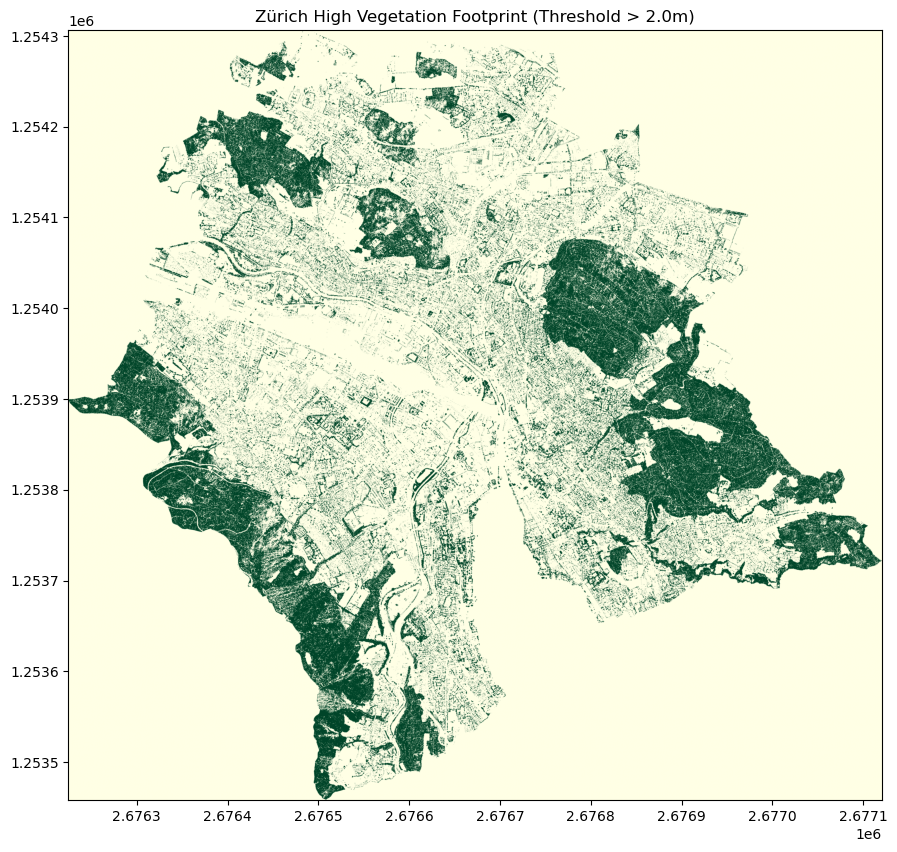

In [3]:
with rasterio.open(GLOBAL_MASK_PATH) as src:
    preview_factor = 15
    preview_data = src.read(1, out_shape=(src.height//preview_factor, src.width//preview_factor))
    
    fig, ax = plt.subplots(figsize=(12, 10))
    rasterio.plot.show(preview_data, transform=src.transform, ax=ax, cmap='YlGn')
    ax.set_title(f"Zürich High Vegetation Footprint (Threshold > {MIN_HEIGHT_M}m)")
    plt.show()

## 4. Extracting Patches for Training

We now use our building anchors to slice 512x512 patches from the processed global mask.

In [ ]:
from PIL import Image # Add this import at the top

gdf_anchors = gpd.read_file(ANCHOR_PATH)

with rasterio.open(GLOBAL_MASK_PATH) as src_global:
    for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
        uid, split = row['unique_id'], row['split']
        out_folder = f"{BASE_OUT}/{split}/{MASK_TASK_NAME}"
        os.makedirs(out_folder, exist_ok=True)
        
        # CHANGED: File extension to .png
        out_path = f"{out_folder}/{uid}_mask.png"
        if os.path.exists(out_path): continue
        
        # Window calculation (Same as before)
        win_minx, win_maxx = row['x_2056'] - CROP_RADIUS_M, row['x_2056'] + CROP_RADIUS_M
        win_miny, win_maxy = row['y_2056'] - CROP_RADIUS_M, row['y_2056'] + CROP_RADIUS_M
        window = from_bounds(win_minx, win_miny, win_maxx, win_maxy, src_global.transform).round()
        
        # Read the patch
        mask_patch = src_global.read(1, window=window, boundless=True, fill_value=0, out_shape=(IMG_SIZE, IMG_SIZE))
        
        # NEW: Save as 8-bit PNG using PIL
        # We multiply by 1 if binary, or keep as is if categorical (0,1,2,3)
        img_mask = Image.fromarray(mask_patch.astype(np.uint8))
        img_mask.save(out_path)

print(f"✅ Mask extraction complete. Files saved as lightweight PNGs in {BASE_OUT}")

  0%|          | 0/10000 [00:00<?, ?it/s]

✅ Mask extraction complete. Files saved as lightweight PNGs in ../data/modular_final


## 5. Overlay Sanity Check
Confirming that the tree canopy masks align perfectly with the aerial imagery.

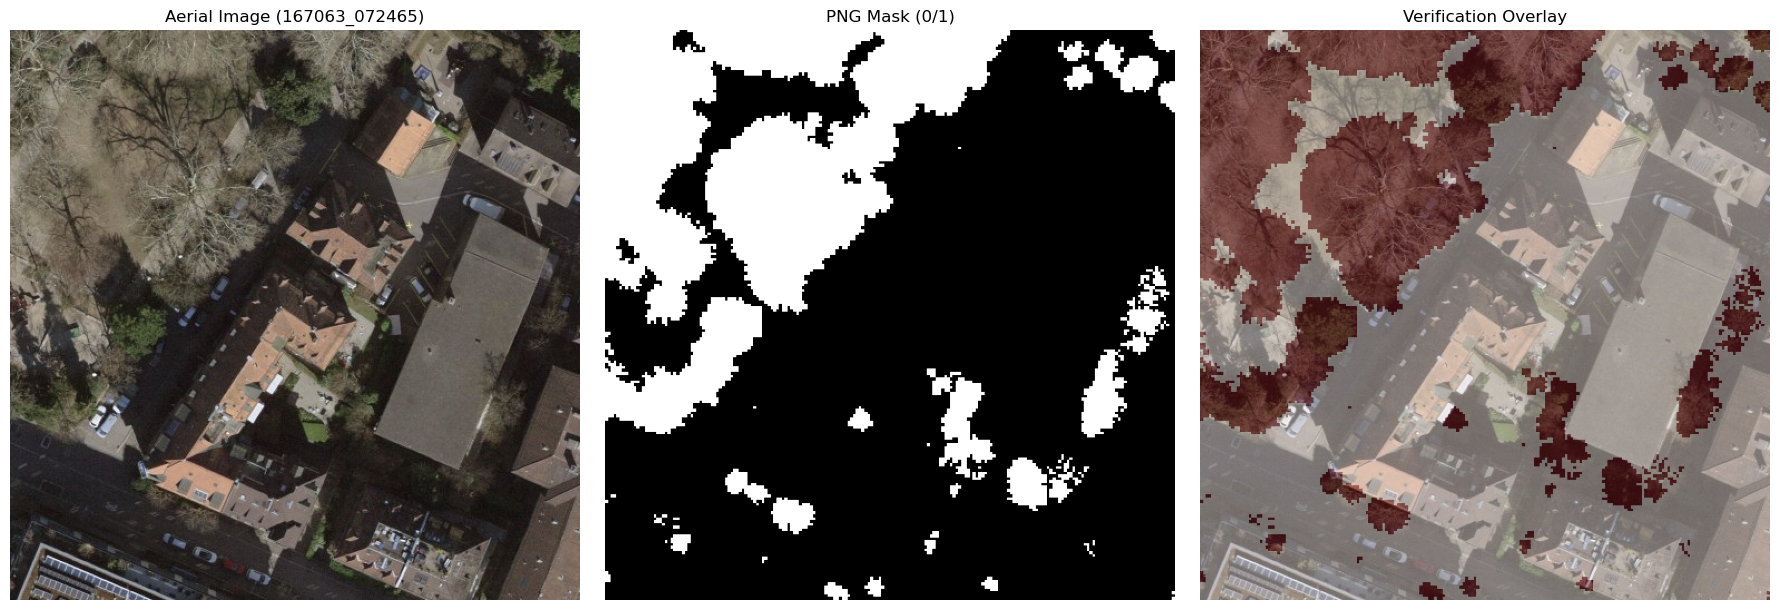

Mask Shape: (512, 512), Unique Values: [0 1]


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Pick a sample
sample = gdf_anchors.sample(1).iloc[0]
uid, split = sample['unique_id'], sample['split']

# 2. Define paths
#img_path = f"{BASE_OUT}/{split}/images/{uid}_swissimage.tif"
img_path = f"{BASE_OUT}/{split}/images/{uid}_swissimage.jpg"
mask_path = f"{BASE_OUT}/{split}/{MASK_TASK_NAME}/{uid}_mask.png"

# 3. Load using Rasterio for image (to handle TIFF) and PIL for mask
# with rasterio.open(img_path) as src:
#     img_array = src.read([1, 2, 3]).transpose(1, 2, 0) # Read RGB channels
img_array = np.array(Image.open(img_path).convert("RGB"))
mask_array = np.array(Image.open(mask_path))

# 4. Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot Aerial
axs[0].imshow(img_array)
axs[0].set_title(f"Aerial Image ({uid})")
axs[0].axis("off")

# Plot Mask
axs[1].imshow(mask_array, cmap="gray")
axs[1].set_title("PNG Mask (0/1)")
axs[1].axis("off")

# Plot Overlay
axs[2].imshow(img_array)
# Use 'Reds' for Built-up, 'Greens' for Vegetation
axs[2].imshow(mask_array, cmap="Reds", alpha=0.4) 
axs[2].set_title("Verification Overlay")
axs[2].axis("off")

plt.tight_layout()
plt.show()

# Verification print
print(f"Mask Shape: {mask_array.shape}, Unique Values: {np.unique(mask_array)}")